In [1]:
# %%
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import softmax, add_self_loops
from sklearn.manifold import TSNE

In [9]:
# %%
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [10]:
class SparseGATAttention(nn.Module):
    def __init__(self,emb_dim, neg_slope=0.2):
        super(SparseGATAttention,self).__init__()
        self.emb_dim = emb_dim
        self.neg_slope = neg_slope
        self.a = nn.Linear(2*emb_dim, 1, bias=False)
    def forward(self, h, edge_index):
        """ 
        h : (N,F')
        edge_index : (2,E) COO format
        """
        src, dst = edge_index
        h_src = h[src]  # (E,F')
        h_dst = h[dst]  # (E,F')
        h_cat = torch.cat([h_src, h_dst], dim=1)  # (E,2F')
        e = self.a(h_cat)
        e = F.leaky_relu(e, self.neg_slope)
        e = e.reshape(-1)
        return e
    
        

In [11]:
# %%
class GATAttention(nn.Module):
    def __init__(self, emb_dim, neg_slope: float = 0.2):
        super(GATAttention, self).__init__()
        self.emb_dim = emb_dim
        self.a_i = nn.Linear(emb_dim, 1, bias=False)
        self.a_j = nn.Linear(emb_dim, 1, bias=False)
        self.neg_slope = neg_slope

    def forward(self, h: torch.Tensor):
        a_input_i = self.a_i(h)
        a_input_j = self.a_j(h)
        e = a_input_i + a_input_j.T
        e = F.leaky_relu(e, negative_slope=self.neg_slope)
        return e

In [12]:
# %%
class SparseGATLayer(nn.Module):
    def __init__(self, in_features, out_features, no_heads: int = 1,
                 dropout: float = 0.2, neg_slope: float = 0.2, concat: bool = True):
        super(SparseGATLayer, self).__init__()
        
        self.no_heads = no_heads
        self.concat = concat
        self.dropout = nn.Dropout(dropout)
        
        self.linear = nn.ModuleList([
            nn.Linear(in_features, out_features, bias=False)
            for _ in range(no_heads)
        ])
        self.attention = nn.ModuleList([
            SparseGATAttention(out_features, neg_slope)
            for _ in range(no_heads)
        ])

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, return_alpha=False):
        x = self.dropout(x)
        src, dst = edge_index
        num_nodes = x.size(0)
        out = []
        all_alpha = []

        for i in range(self.no_heads):
            h = self.linear[i](x)
            e = self.attention[i](h, edge_index)
            alpha = softmax(e, dst, num_nodes=num_nodes)
            alpha = torch.nan_to_num(alpha, nan=0.0)

            if return_alpha:
                dense_alpha = torch.zeros((num_nodes, num_nodes), device=x.device)
                dense_alpha.index_put_((src, dst), alpha, accumulate=True)
                all_alpha.append(dense_alpha)

            alpha = self.dropout(alpha)
            msg = alpha.unsqueeze(-1) * h[src]
            out_i = torch.zeros((num_nodes, h.size(1)), device=x.device)
            out_i.index_add_(0, dst, msg)
            out.append(out_i)

        if self.concat:
            out = torch.cat(out, dim=1)
        else:
            out = torch.mean(torch.stack(out, dim=0), dim=0)

        if return_alpha:
            return out, all_alpha

        return out

In [13]:
# %%
class GAT(nn.Module):
    def __init__(self, in_features, hidden_features: list, out_features: int,
                 num_heads: list, dropout: float = 0.2, neg_slope: float = 0.2):
        super(GAT, self).__init__()
        self.layers = nn.ModuleList()

        for i in range(len(hidden_features)):
            in_dim = in_features if i == 0 else hidden_features[i - 1] * num_heads[i - 1]
            out_dim = hidden_features[i]
            self.layers.append(
                SparseGATLayer(in_dim, out_dim, no_heads=num_heads[i],
                               dropout=dropout, neg_slope=neg_slope, concat=True)
            )

        in_dim = hidden_features[-1] * num_heads[-1]
        self.layers.append(
            SparseGATLayer(in_dim, out_features, no_heads=1,
                           dropout=dropout, neg_slope=neg_slope, concat=False)
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        for i, layer in enumerate(self.layers):
            x = layer(x, edge_index)
            if i < len(self.layers) - 1:
                x = F.elu(x)
        return F.log_softmax(x, dim=1)

In [14]:
# %%
# dataset = Planetoid(root="data", name="Cora")
# data = dataset[0]
#! earlier there was no normalizartion
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(
    root='/tmp/Cora',
    name='Cora',
    transform=NormalizeFeatures()   
)
data = dataset[0]

In [15]:
# %%
N = data.num_nodes
edge_index, _ = add_self_loops(data.edge_index, num_nodes=N)

A = torch.zeros((N, N), dtype=torch.float32)
A[edge_index[0], edge_index[1]] = 1.0

A = A + A.T
A[A > 1] = 1.0

In [16]:
# %%
x = data.x.to(device)
y = data.y.to(device)
A = A.to(device)
edge_index = edge_index.to(device)

train_mask = data.train_mask.to(device)
val_mask = data.val_mask.to(device)
test_mask = data.test_mask.to(device)

In [17]:
# %%
def glorot_init(model):
    for param in model.parameters():
        if param.dim() > 1:
            nn.init.xavier_uniform_(param)
        else:
            nn.init.zeros_(param)


def accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


def compute_attention_entropy(alpha, adj):
    eps = 1e-10
    alpha = alpha * adj

    # alpha is stored as [src, dst], but normalization is over dst
    # so entropy should be computed per destination node
    log_alpha = torch.log(alpha + eps)
    entropy_per_node = -(alpha * log_alpha).sum(dim=0)
    return entropy_per_node.mean().item()

In [18]:
import os

SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

In [19]:
def load_model_for_run(run_idx, model, device):
    load_path = os.path.join(SAVE_DIR, f"gat_run_{run_idx}.pt")

    checkpoint = torch.load(load_path, map_location=device)

    model = model(
        in_features=data.num_node_features,
        hidden_features=[8],
        out_features=dataset.num_classes,
        num_heads=[8],
        dropout=0.6,
        neg_slope=0.2
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded Run {run_idx}")
    print(f"Val Acc: {checkpoint['val_acc']:.4f}, Epoch: {checkpoint['epoch']}")

    return model

In [20]:
# %%
def train_one_run(seed, run_idx=0):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = GAT(
        in_features=data.num_node_features,
        hidden_features=[8],
        out_features=dataset.num_classes,
        num_heads=[8],
        dropout=0.6,
        neg_slope=0.2
    ).to(device)

    glorot_init(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = nn.NLLLoss()

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None
    counter = 0
    patience = 100

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "entropy_mean": [],
        "entropy_heads": []
    }

    pbar = tqdm(
        range(1000),
        desc=f"Run {run_idx+1} | Seed {seed}",
        position=1,
        leave=False,
        dynamic_ncols=True
    )

    for epoch in pbar:
        model.train()
        optimizer.zero_grad()

        out = model(x, edge_index)
        loss = criterion(out[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_out = model(x, edge_index)
            train_loss_value = criterion(train_out[train_mask], y[train_mask]).item()
            train_acc = accuracy(train_out[train_mask], y[train_mask])

            val_out = train_out
            val_loss_value = criterion(val_out[val_mask], y[val_mask]).item()
            val_acc = accuracy(val_out[val_mask], y[val_mask])

            # Entropy from the first layer, pre-dropout attention
            layer = model.layers[0]
            _, alpha_heads = layer(x, edge_index, return_alpha=True)
            entropies = [compute_attention_entropy(a, A) for a in alpha_heads]
            mean_entropy = float(np.mean(entropies))

        improved = False
        if val_loss_value < best_val_loss:
            best_val_loss = val_loss_value
            best_val_acc = val_acc
            improved = True

        if improved:
            best_state = copy.deepcopy(model.state_dict())

            # SAVE MODEL
            save_path = os.path.join(SAVE_DIR, f"gat_run_{run_idx}.pt")
            torch.save({
                "model_state_dict": best_state,
                "val_loss": best_val_loss,
                "val_acc": best_val_acc,
                "epoch": epoch,
                "seed": seed
            }, save_path)

            counter = 0
        else:
            counter += 1

        history["train_loss"].append(train_loss_value)
        history["val_loss"].append(val_loss_value)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["entropy_mean"].append(mean_entropy)
        history["entropy_heads"].append(entropies)

        pbar.set_postfix(
            train_loss=f"{train_loss_value:.4f}",
            val_loss=f"{val_loss_value:.4f}",
            val_acc=f"{val_acc:.4f}",
            entropy=f"{mean_entropy:.4f}",
            patience=counter
        )

        if counter >= patience:
            break

    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_out = model(x, edge_index)
        test_acc = accuracy(test_out[test_mask], y[test_mask])

    return test_acc, model, history, best_val_acc

In [21]:
# %%
num_runs = 50

test_accuracies = []
best_val_accs = []
histories = []
models = []

run_bar = tqdm(
    range(num_runs),
    desc="Runs",
    position=0,
    leave=True,
    dynamic_ncols=True
)

for run in run_bar:
    acc, model, history, best_val_acc = train_one_run(seed + run, run_idx=run)
    test_accuracies.append(acc)
    best_val_accs.append(best_val_acc)
    histories.append(history)
    models.append(model)

    tqdm.write(
        f"Run {run+1:02d} | Test Acc: {acc:.4f} | Best Val Acc: {best_val_acc:.4f}"
    )

mean_acc = np.mean(test_accuracies)
std_acc = np.std(test_accuracies)

print(f"\nFinal Result over {num_runs} runs:")
print(f"Test Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

Runs:   2%|▏         | 1/50 [01:17<1:03:00, 77.15s/it]

Run 01 | Test Acc: 0.8250 | Best Val Acc: 0.8020


Runs:   4%|▍         | 2/50 [02:44<1:06:43, 83.40s/it]

Run 02 | Test Acc: 0.8280 | Best Val Acc: 0.7960


Runs:   6%|▌         | 3/50 [04:09<1:05:35, 83.74s/it]

...

Run 48 | Test Acc: 0.8310 | Best Val Acc: 0.8040


Runs:  98%|█████████▊| 49/50 [1:00:47<01:02, 62.68s/it]

Run 49 | Test Acc: 0.8230 | Best Val Acc: 0.8040


Runs: 100%|██████████| 50/50 [1:01:33<00:00, 73.88s/it]

Run 50 | Test Acc: 0.8260 | Best Val Acc: 0.8040

Final Result over 50 runs:
Test Accuracy: 0.8273 ± 0.0035


## What does the attention entropy represent?

Attention entropy is a measure of uncertainty in each node's attention distribution over neighbors.
For a node i, GAT computes:
$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k \in \mathcal{N}(i)} \exp(e_{ik})}$$

where $e_{ij}$ is the attention score between node i and its neighbor j, and $\mathcal{N}(i)$ is the set of neighbors of node i.
Entropy is calculated as:
$$H(i) = -\sum_{j \in \mathcal{N}(i)} \alpha_{ij} \log(\alpha_{ij})$$

Interpretation:
- **Low Attention Entropy**: one or a few neighbors dominate the attention mass (more focused attention).
- **High Attention Entropy**: attention is spread more uniformly across many neighbors (less selective attention).

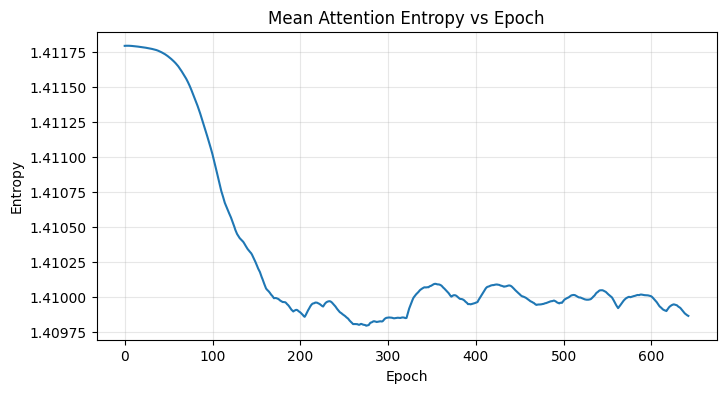

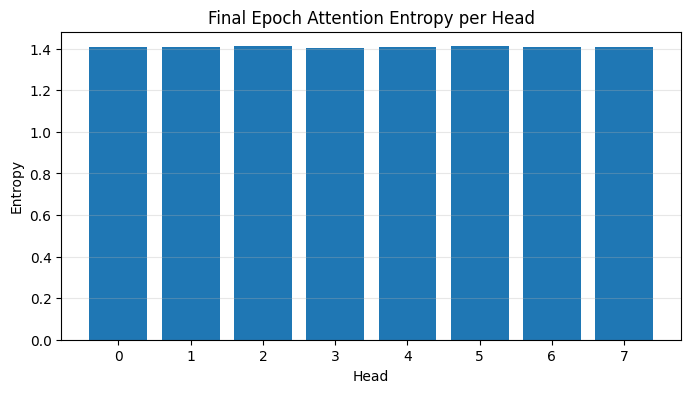

In [22]:
# %%
best_run_idx = int(np.argmax(best_val_accs))
best_history = histories[best_run_idx]

entropy_curve = np.array(best_history["entropy_mean"])
final_head_entropies = np.array(best_history["entropy_heads"][-1])

plt.figure(figsize=(8, 4))
plt.plot(entropy_curve)
plt.title("Mean Attention Entropy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Entropy")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(final_head_entropies)), final_head_entropies)
plt.title("Final Epoch Attention Entropy per Head")
plt.xlabel("Head")
plt.ylabel("Entropy")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [23]:
final_model = load_model_for_run(best_run_idx, GAT, device)

Loaded Run 32
Val Acc: 0.8100, Epoch: 542


In [24]:
# %%
@torch.no_grad()
def get_embeddings(model):
    model.eval()
    x_emb = x

    for layer in model.layers[:-1]:
        x_emb = layer(x_emb, edge_index)
        x_emb = F.elu(x_emb)

    return x_emb.cpu().numpy()

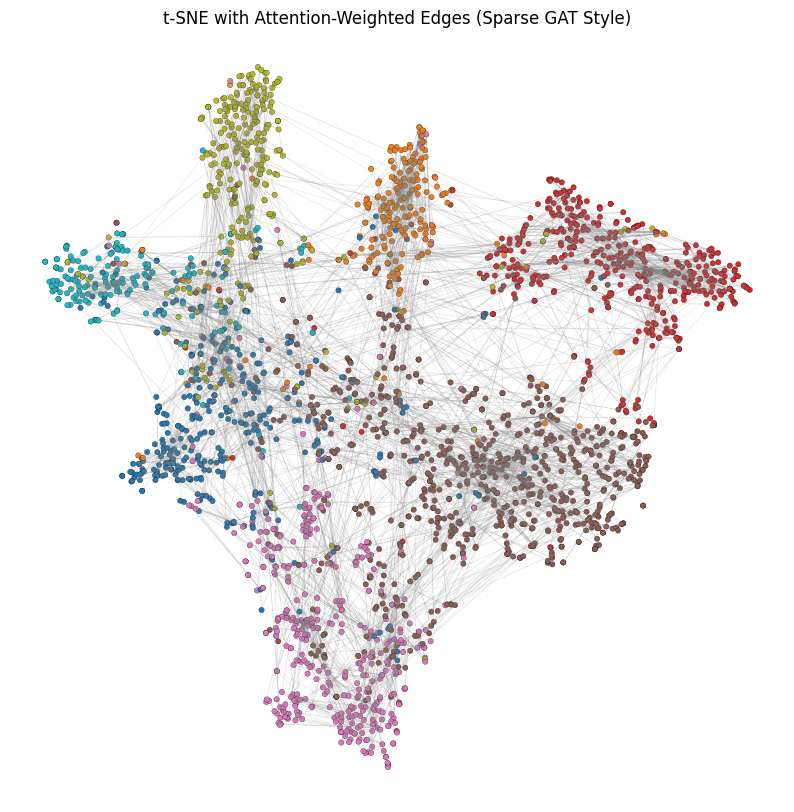

In [26]:
# %%
import matplotlib.pyplot as plt
viz_model = models[best_run_idx]

@torch.no_grad()
def get_attention_matrix(model):
    model.eval()
    layer = model.layers[0]

    _, alpha_heads = layer(x, edge_index, return_alpha=True)

    # Stack heads: (num_heads, N, N)
    alpha_heads = torch.stack(alpha_heads, dim=0)

    # Symmetric aggregation (paper style)
    alpha_sum = alpha_heads.sum(dim=0)  # sum over heads
    alpha_sym = alpha_sum + alpha_sum.T

    return alpha_sym.cpu().numpy()


# %%
# Get embeddings
emb = get_embeddings(viz_model)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(emb)

labels = y.cpu().numpy()

# Get attention
alpha = get_attention_matrix(viz_model)

# %%
plt.figure(figsize=(10, 10))

# ---- DRAW EDGES ----
threshold = np.percentile(alpha, 99)  # only strongest edges

for i in range(len(emb_2d)):
    for j in range(i + 1, len(emb_2d)):
        if A[i, j] > 0 and alpha[i, j] > threshold:
            x1, y1 = emb_2d[i]
            x2, y2 = emb_2d[j]

            weight = alpha[i, j]

            plt.plot(
                [x1, x2],
                [y1, y2],
                linewidth=0.5,
                alpha=0.1 + 0.4 * (weight / alpha.max()),
                color="gray"
            )

# ---- DRAW NODES ----
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=15,
    edgecolors="k",
    linewidths=0.2
)

plt.title("t-SNE with Attention-Weighted Edges (Sparse GAT Style)")
plt.axis("off")
plt.show()